<a href="https://colab.research.google.com/github/Anthony18xd/Diagrama-de-Dispersi-n/blob/main/Diagrama_de_Dispersi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS: RELACIÓN ENTRE COMMITS Y DEFECTOS REPORTADOS

📊 Dataset (12 sprints):

   Sprint  Commits  Defectos
0      S1      150        12
1      S2      180        14
2      S3      210        17
3      S4      170        13
4      S5      260        21
5      S6      300        25
6      S7      140        10
7      S8      220        18
8      S9      275        23
9     S10      195        16
10    S11      165        12
11    S12      240        19


📈 ESTADÍSTICOS DESCRIPTIVOS

🔹 COMMITS:
  • Media:                208.75
  • Mediana:              202.50
  • Desviación estándar:  51.40
  • Varianza:             2641.48
  • Mínimo:               140
  • Máximo:               300
  • Rango:                160

🔹 DEFECTOS:
  • Media:                16.67
  • Mediana:              16.50
  • Desviación estándar:  4.72
  • Varianza:             22.24
  • Mínimo:               10
  • Máximo:               25
  • Rango:                15


🔗 CORRELACIÓN DE PEARSON

  • Coeficiente de corr

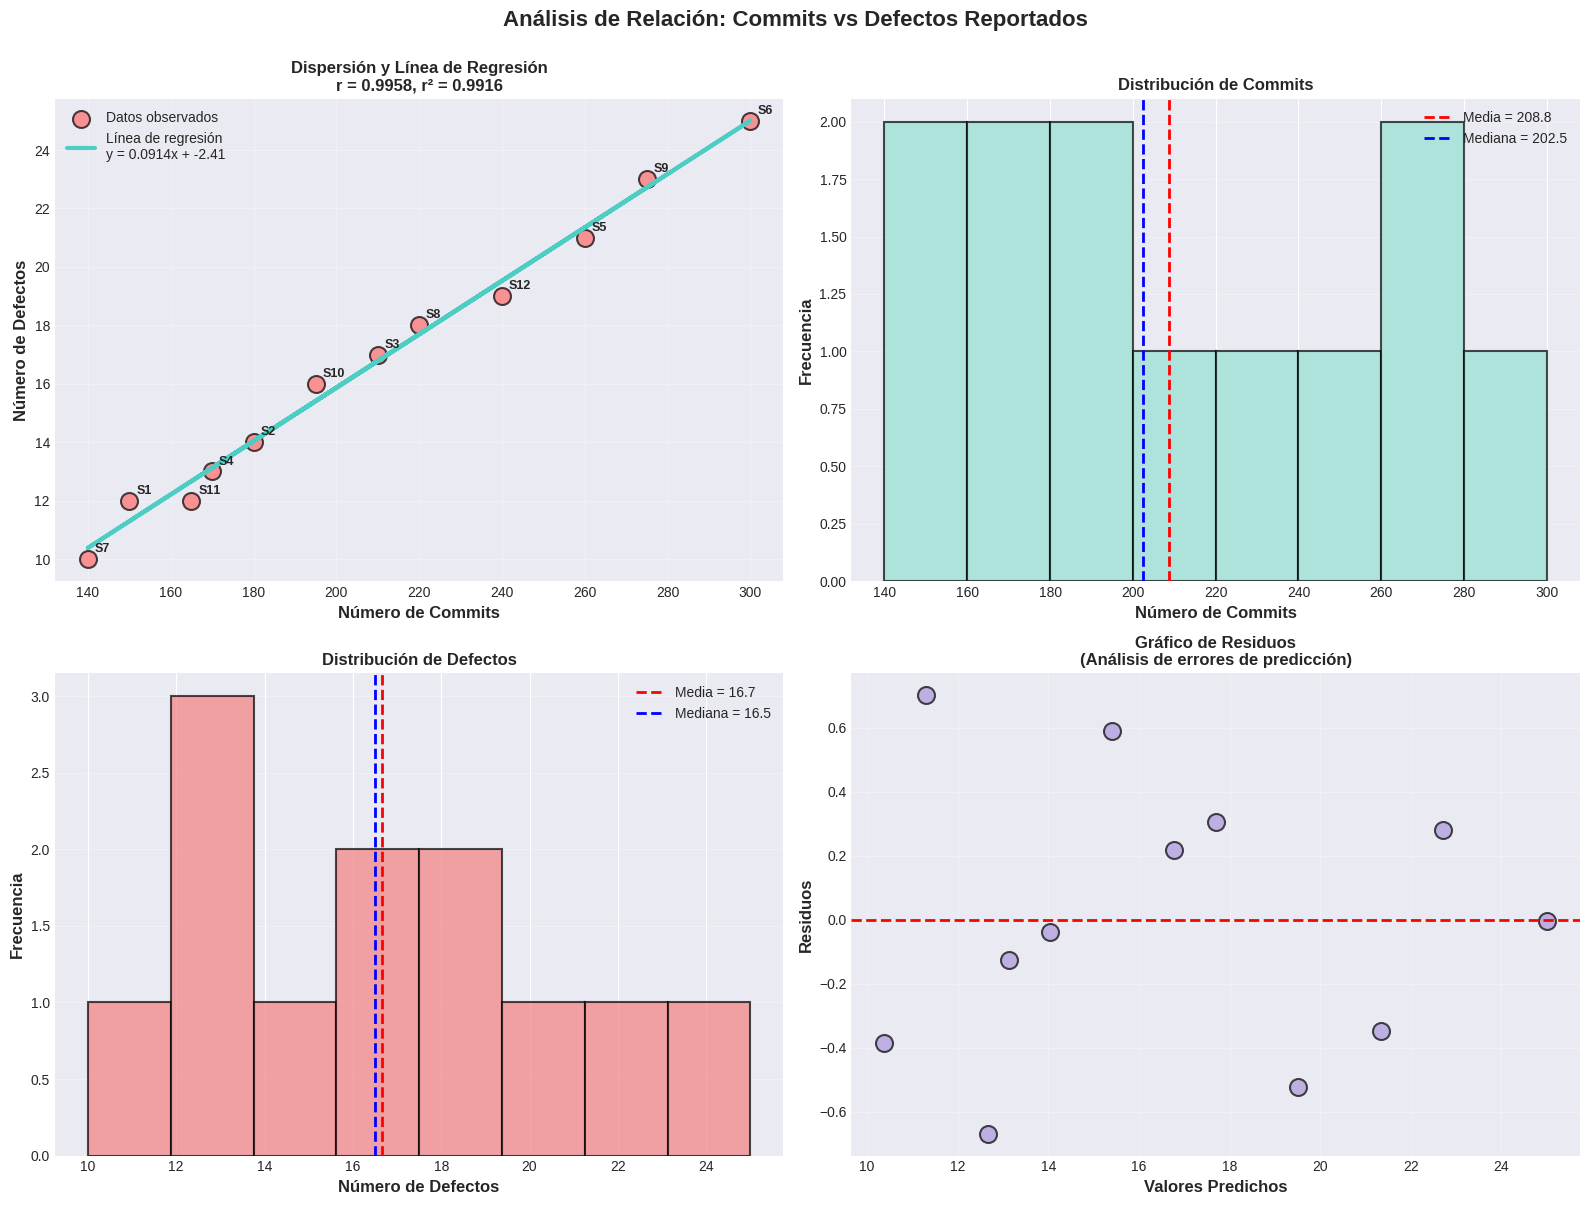

📋 TABLA RESUMEN DE RESULTADOS

                  Métrica   Valor
           Media Commits  208.75
          Media Defectos   16.67
      Desv. Std. Commits   51.40
     Desv. Std. Defectos    4.72
         Correlación (r)  0.9958
Coef. Determinación (r²)  0.9916
                 P-value  0.0000
           Pendiente (m)  0.0914
          Intercepto (b) -2.4078
                    RMSE  0.4151


✅ Análisis completado exitosamente!
📊 Todos los gráficos han sido generados.
🎯 Revisa los resultados arriba para tu tarea.



In [1]:
# Análisis de Relación entre Commits y Defectos
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. CARGAR LOS DATOS
# ============================================

# Dataset de 12 sprints
data = {
    'Sprint': ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12'],
    'Commits': [150, 180, 210, 170, 260, 300, 140, 220, 275, 195, 165, 240],
    'Defectos': [12, 14, 17, 13, 21, 25, 10, 18, 23, 16, 12, 19]
}

df = pd.DataFrame(data)

print("="*60)
print("ANÁLISIS: RELACIÓN ENTRE COMMITS Y DEFECTOS REPORTADOS")
print("="*60)
print("\n📊 Dataset (12 sprints):\n")
print(df)
print("\n" + "="*60 + "\n")

# ============================================
# 2. ESTADÍSTICOS DESCRIPTIVOS
# ============================================

print("📈 ESTADÍSTICOS DESCRIPTIVOS")
print("="*60)

# Para Commits
commits = df['Commits'].values
print("\n🔹 COMMITS:")
print(f"  • Media:                {np.mean(commits):.2f}")
print(f"  • Mediana:              {np.median(commits):.2f}")
print(f"  • Desviación estándar:  {np.std(commits, ddof=1):.2f}")
print(f"  • Varianza:             {np.var(commits, ddof=1):.2f}")
print(f"  • Mínimo:               {np.min(commits)}")
print(f"  • Máximo:               {np.max(commits)}")
print(f"  • Rango:                {np.max(commits) - np.min(commits)}")

# Para Defectos
defectos = df['Defectos'].values
print("\n🔹 DEFECTOS:")
print(f"  • Media:                {np.mean(defectos):.2f}")
print(f"  • Mediana:              {np.median(defectos):.2f}")
print(f"  • Desviación estándar:  {np.std(defectos, ddof=1):.2f}")
print(f"  • Varianza:             {np.var(defectos, ddof=1):.2f}")
print(f"  • Mínimo:               {np.min(defectos)}")
print(f"  • Máximo:               {np.max(defectos)}")
print(f"  • Rango:                {np.max(defectos) - np.min(defectos)}")

print("\n" + "="*60 + "\n")

# ============================================
# 3. CORRELACIÓN DE PEARSON
# ============================================

print("🔗 CORRELACIÓN DE PEARSON")
print("="*60)

# Calcular correlación de Pearson
r_pearson, p_value = pearsonr(commits, defectos)

print(f"\n  • Coeficiente de correlación (r): {r_pearson:.4f}")
print(f"  • Valor p (p-value):              {p_value:.4f}")

# Interpretación de la correlación
print("\n📊 Interpretación de la correlación:")
if abs(r_pearson) < 0.3:
    fuerza = "débil"
elif abs(r_pearson) < 0.7:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

if r_pearson > 0:
    direccion = "positiva"
else:
    direccion = "negativa"

print(f"  • Existe una correlación {fuerza} {direccion}")
print(f"  • r² (coeficiente de determinación): {r_pearson**2:.4f}")
print(f"  • El {r_pearson**2*100:.2f}% de la variabilidad en defectos")
print(f"    puede explicarse por el número de commits")

# Significancia estadística
if p_value < 0.05:
    print(f"  • ✅ La correlación ES estadísticamente significativa (p < 0.05)")
else:
    print(f"  • ❌ La correlación NO es estadísticamente significativa (p ≥ 0.05)")

print("\n" + "="*60 + "\n")

# ============================================
# 4. PREDICCIÓN DE LÍNEA SIMPLE (Regresión Lineal)
# ============================================

print("📉 PREDICCIÓN - REGRESIÓN LINEAL SIMPLE")
print("="*60)

# Calcular pendiente (m) e intercepto (b) usando mínimos cuadrados
x = commits
y = defectos

n = len(x)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x ** 2)

# Fórmulas de regresión lineal
m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
b = (sum_y - m * sum_x) / n

print(f"\n  • Ecuación de regresión: y = {m:.4f}x + {b:.4f}")
print(f"  • Pendiente (m):         {m:.4f}")
print(f"  • Intercepto (b):        {b:.4f}")

# Predicciones
y_pred = m * x + b

# Error cuadrático medio
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"\n  • Error cuadrático medio (MSE):  {mse:.4f}")
print(f"  • Raíz del error cuadrático (RMSE): {rmse:.4f}")

# Ejemplo de predicción
ejemplo_commits = 200
ejemplo_defectos = m * ejemplo_commits + b
print(f"\n  • Ejemplo: Si hay {ejemplo_commits} commits, ")
print(f"    se esperan aproximadamente {ejemplo_defectos:.0f} defectos")

print("\n" + "="*60 + "\n")

# ============================================
# 5. INTERPRETACIÓN FINAL
# ============================================

print("💡 INTERPRETACIÓN Y CONCLUSIONES")
print("="*60)

print("\nBased on el análisis realizado:\n")

if r_pearson > 0.7:
    print("✅ EXISTE una relación FUERTE y POSITIVA entre commits y defectos:")
    print("   • Mayor número de commits está asociado con más defectos")
    print("   • Esto sugiere que más actividad de código genera más bugs")
elif r_pearson > 0.3:
    print("⚠️ EXISTE una relación MODERADA y POSITIVA entre commits y defectos:")
    print("   • Hay cierta tendencia: más commits → más defectos")
    print("   • Sin embargo, otros factores también influyen")
else:
    print("❌ La relación entre commits y defectos es DÉBIL:")
    print("   • El número de commits no es un buen predictor de defectos")
    print("   • Otros factores tienen mayor influencia")

print("\n📌 Recomendaciones:")
print("   • Implementar revisiones de código más rigurosas")
print("   • Considerar la complejidad del código, no solo la cantidad")
print("   • Mejorar las pruebas automatizadas antes de cada commit")
print("   • Analizar qué tipo de commits generan más defectos")

print("\n" + "="*60 + "\n")

# ============================================
# 6. GRÁFICO DE DISPERSIÓN
# ============================================

print("📊 Generando gráfico de dispersión...\n")

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Relación: Commits vs Defectos Reportados',
             fontsize=16, fontweight='bold', y=1.00)

# ===== GRÁFICO 1: Dispersión con línea de regresión =====
ax1 = axes[0, 0]
ax1.scatter(commits, defectos, s=150, alpha=0.7, color='#FF6B6B',
            edgecolors='black', linewidth=1.5, label='Datos observados')
ax1.plot(commits, y_pred, color='#4ECDC4', linewidth=3,
         label=f'Línea de regresión\ny = {m:.4f}x + {b:.2f}')

# Añadir etiquetas a cada punto
for i, sprint in enumerate(df['Sprint']):
    ax1.annotate(sprint, (commits[i], defectos[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax1.set_xlabel('Número de Commits', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Defectos', fontsize=12, fontweight='bold')
ax1.set_title(f'Dispersión y Línea de Regresión\nr = {r_pearson:.4f}, r² = {r_pearson**2:.4f}',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== GRÁFICO 2: Distribución de Commits =====
ax2 = axes[0, 1]
ax2.hist(commits, bins=8, color='#95E1D3', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(np.mean(commits), color='red', linestyle='--', linewidth=2,
            label=f'Media = {np.mean(commits):.1f}')
ax2.axvline(np.median(commits), color='blue', linestyle='--', linewidth=2,
            label=f'Mediana = {np.median(commits):.1f}')
ax2.set_xlabel('Número de Commits', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax2.set_title('Distribución de Commits', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# ===== GRÁFICO 3: Distribución de Defectos =====
ax3 = axes[1, 0]
ax3.hist(defectos, bins=8, color='#F38181', alpha=0.7, edgecolor='black', linewidth=1.5)
ax3.axvline(np.mean(defectos), color='red', linestyle='--', linewidth=2,
            label=f'Media = {np.mean(defectos):.1f}')
ax3.axvline(np.median(defectos), color='blue', linestyle='--', linewidth=2,
            label=f'Mediana = {np.median(defectos):.1f}')
ax3.set_xlabel('Número de Defectos', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax3.set_title('Distribución de Defectos', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# ===== GRÁFICO 4: Residuos =====
ax4 = axes[1, 1]
residuos = defectos - y_pred
ax4.scatter(y_pred, residuos, s=150, alpha=0.7, color='#AA96DA',
            edgecolors='black', linewidth=1.5)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Valores Predichos', fontsize=12, fontweight='bold')
ax4.set_ylabel('Residuos', fontsize=12, fontweight='bold')
ax4.set_title('Gráfico de Residuos\n(Análisis de errores de predicción)',
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. TABLA RESUMEN FINAL
# ============================================

print("="*60)
print("📋 TABLA RESUMEN DE RESULTADOS")
print("="*60)

# Crear tabla resumen
resultados = pd.DataFrame({
    'Métrica': [
        'Media Commits',
        'Media Defectos',
        'Desv. Std. Commits',
        'Desv. Std. Defectos',
        'Correlación (r)',
        'Coef. Determinación (r²)',
        'P-value',
        'Pendiente (m)',
        'Intercepto (b)',
        'RMSE'
    ],
    'Valor': [
        f'{np.mean(commits):.2f}',
        f'{np.mean(defectos):.2f}',
        f'{np.std(commits, ddof=1):.2f}',
        f'{np.std(defectos, ddof=1):.2f}',
        f'{r_pearson:.4f}',
        f'{r_pearson**2:.4f}',
        f'{p_value:.4f}',
        f'{m:.4f}',
        f'{b:.4f}',
        f'{rmse:.4f}'
    ]
})

print("\n", resultados.to_string(index=False))
print("\n" + "="*60)

print("\n✅ Análisis completado exitosamente!")
print("📊 Todos los gráficos han sido generados.")
print("🎯 Revisa los resultados arriba para tu tarea.\n")